In [6]:
import pandas as pd
import re

# Use your Desktop path
df = pd.read_csv(r'C:\Users\Omar\Desktop\data\Customers.csv')

def clean_income(val):
    if pd.isnull(val):
        return None
    cleaned = re.sub(r'[^\d.]', '', str(val))
    if cleaned == '' or cleaned == '.':
        return None
    try:
        num = float(cleaned)
        if num.is_integer():
            return int(num)
        return num
    except:
        return None

df['Income'] = df['Income'].apply(clean_income)

# Save cleaned file to Desktop as well
df.to_csv(r'C:\Users\Omar\Desktop\Customers.csv', index=False)

In [32]:
import pandas as pd
import numpy as np

# تحميل البيانات
df = pd.read_csv(r'C:\Users\Omar\Desktop\Customers.csv')

# تصحيح القيم الشاذة في الدخل
df.loc[df['Income'] < 1000, 'Income'] = np.nan

# تعويض القيم المفقودة في Age بالوسيط (median)
df.fillna({'Age': df['Age'].median()}, inplace=True)

# تعويض القيم المفقودة في Income بقيمة عشوائية من القيم غير المفقودة في العمود نفسه
df['Income'] = df['Income'].apply(
    lambda x: np.random.choice(df['Income'].dropna()) if pd.isnull(x) else x
)

# حفظ الملف بعد التنظيف
df.to_csv(r'C:\Users\Omar\Desktop\Customers.csv', index=False)

# التحقق من النتائج
print(df.head())
print("Missing values after cleaning:\n", df.isnull().sum())






   CustomerID          Name  Age  Gender   Income Region
0           1  yara ramadan   35       F  21000.0  North
1           2    Sara Ammar   26  Female  17250.0  South
2           3   Leen Saleem   25  Female  16000.0  South
3           4   zena Khaled   41  Female  24000.0   East
4           5     Dema Omar   18  Female  12500.0      N
Missing values after cleaning:
 CustomerID    0
Name          0
Age           0
Gender        0
Income        0
Region        0
dtype: int64


In [2]:
import pyodbc
print(pyodbc.drivers())

['SQL Server', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 17 for SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']


Empty DataFrame
Columns: [ProductName, TotalSales]
Index: []


C:\Users\Omar\AppData\Local\Temp\ipykernel_8936\3458585496.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales = pd.read_sql(query, conn)


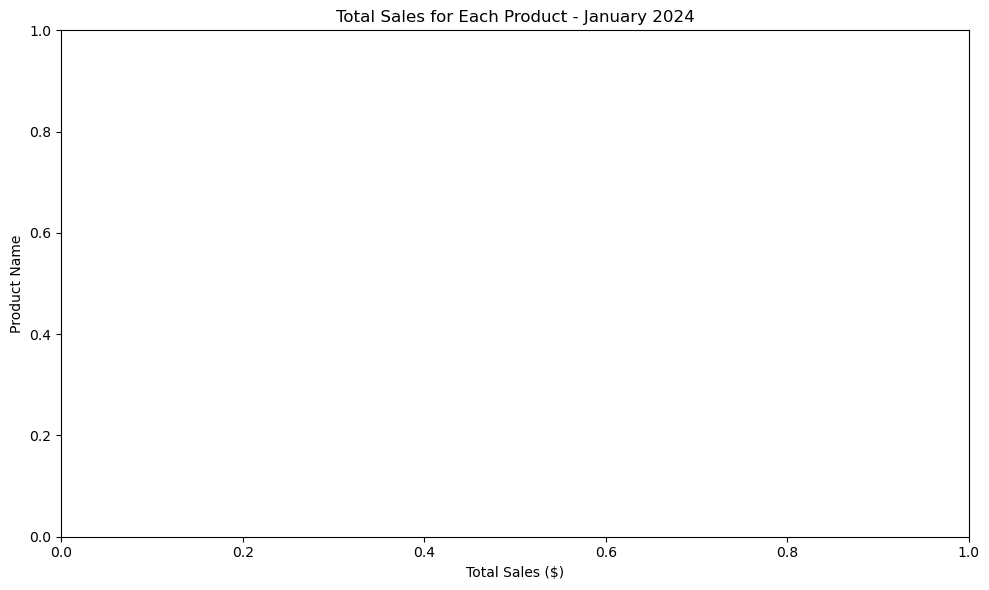

                         
0  2020-01-01  2024-12-31


C:\Users\Omar\AppData\Local\Temp\ipykernel_8936\3458585496.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(query, conn))


In [9]:
# 1. استيراد المكتبات
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. الاتصال بقاعدة البيانات
conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=DESKTOP-FLTSJMO\\SQLEXPRESS;"
    "Database=Data_Project;"
    "Trusted_Connection=yes;"
)

# 3. استعلام SQL لجلب إجمالي المبيعات لكل منتج في يناير 2024
query = """
SELECT 
    Products.ProductName,
    SUM(Sales.TotalAmount) AS TotalSales
FROM Sales
JOIN Products ON Sales.ProductID = Products.ProductID
WHERE SaleDate >= '2024-01-01' AND SaleDate < '2024-02-01'
GROUP BY Products.ProductName
ORDER BY TotalSales DESC;
"""

# 4. تحميل البيانات إلى DataFrame
df_sales = pd.read_sql(query, conn)
print(df_sales)

# 5. رسم البيانات باستخدام Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=df_sales, x='TotalSales', y='ProductName', palette='Blues_d')
plt.title('Total Sales for Each Product - January 2024')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')

# 6. كتابة الأرقام على الأعمدة
for index, value in enumerate(df_sales['TotalSales']):
    plt.text(value, index, str(value), va='center')

plt.tight_layout()
plt.show()
query = "SELECT MIN(SaleDate), MAX(SaleDate) FROM Sales"
print(pd.read_sql(query, conn))



C:\Users\Omar\AppData\Local\Temp\ipykernel_22644\2992403541.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_low_stock = pd.read_sql(query, conn)
C:\Users\Omar\AppData\Local\Temp\ipykernel_22644\2992403541.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_low_stock, x='StockQuantity', y='ProductName', palette='Reds_r')


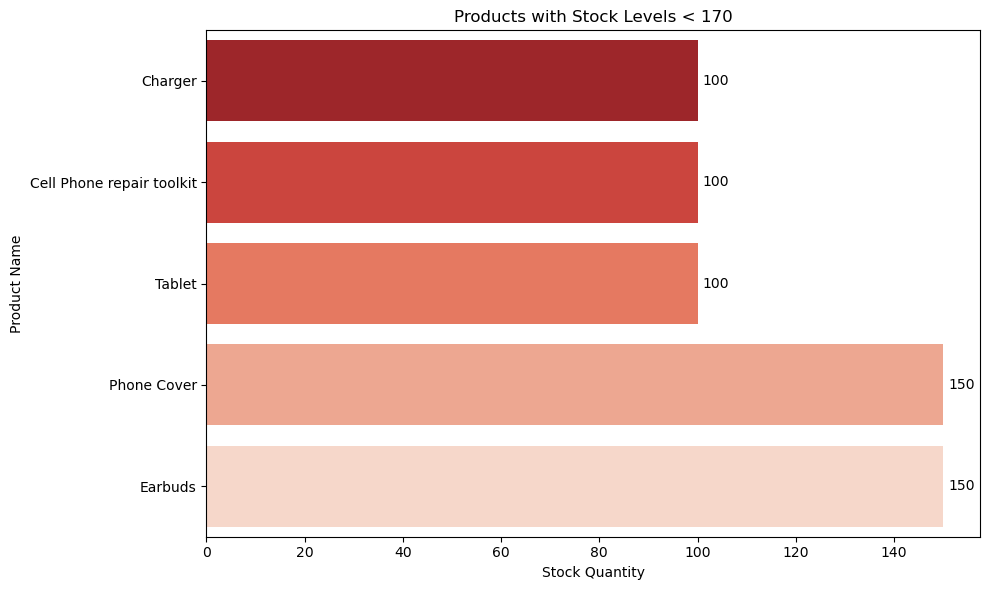

In [22]:
import pyodbc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# الاتصال بقاعدة البيانات
conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=DESKTOP-FLTSJMO\\SQLEXPRESS;"
    "Database=Data_Project;"
    "Trusted_Connection=yes;"
)

# استعلام المنتجات منخفضة المخزون
query = """
SELECT ProductName, StockQuantity
FROM dbo.Products
WHERE StockQuantity < 170
ORDER BY StockQuantity ASC;
"""

df_low_stock = pd.read_sql(query, conn)


plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_low_stock, x='StockQuantity', y='ProductName', palette='Reds_r')
plt.title('Products with Stock Levels < 170')
plt.xlabel('Stock Quantity')
plt.ylabel('Product Name')

# كتابة الأرقام بشكل ديناميكي بناءً على كل عمود
for p in ax.patches:
    ax.text(p.get_width() + 1,  # X position
            p.get_y() + p.get_height() / 2,  # Y position (منتصف العمود)
            int(p.get_width()),  # القيمة
            va='center')

plt.tight_layout()
plt.show()



C:\Users\Omar\AppData\Local\Temp\ipykernel_27952\806054869.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_age = pd.read_sql(query, conn)


   Age
0   35
1   26
2   25
3   26
4   24


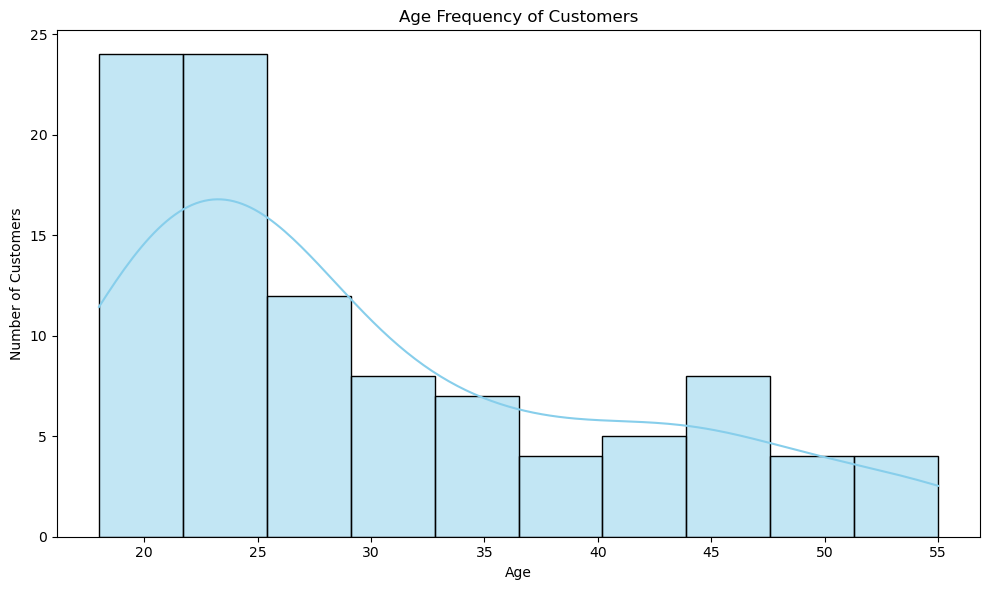

In [35]:
query = """
SELECT Age
FROM dbo.Customers
WHERE Age IS NOT NULL
"""
df_age = pd.read_sql(query, conn)
print(df_age.head())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df_age, x='Age', bins=10, kde=True, color='skyblue')
plt.title('Age Frequency of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


R² (Model Accuracy): 0.31844826026835227
Intercept (الثابت): -5532.951106918451
Coefficient for Income: 0.14970091706710495
Coefficient for Age: 277.1934873824881


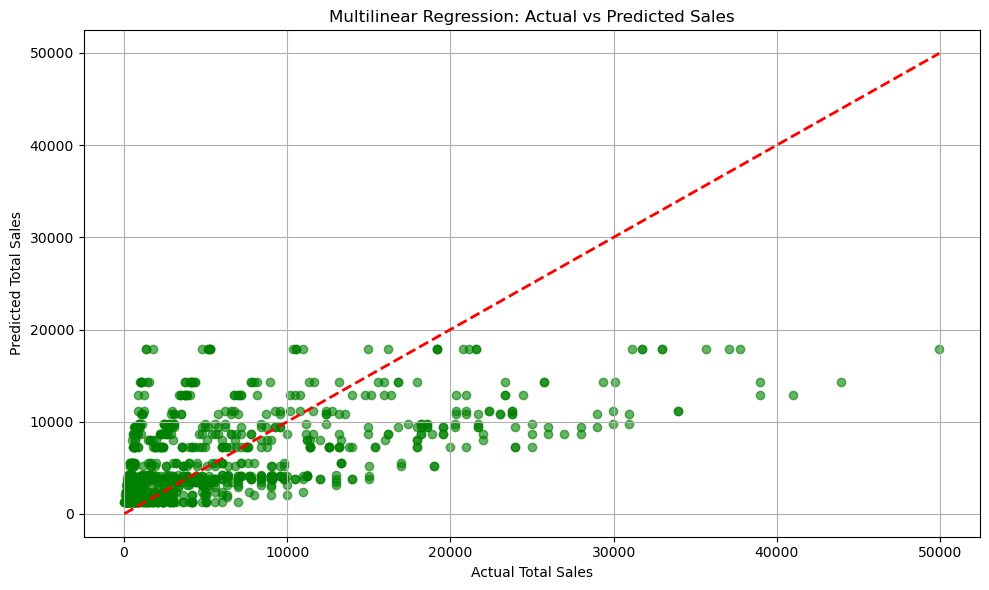

In [5]:
# Regression Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


customers_df = pd.read_csv(r"C:\Users\Omar\Desktop\Customers.csv")
sales_df = pd.read_csv(r"C:\Users\Omar\Desktop\Data\Sales.csv")



merged_df = pd.merge(sales_df, customers_df, on="CustomerID")




X = merged_df[['Income', 'Age']]         
y = merged_df['TotalAmount']             


model = LinearRegression().fit(X, y)


r_squared = model.score(X, y)
intercept = model.intercept_
coefficients = model.coef_

print("R² (Model Accuracy):", r_squared)
print("Intercept (الثابت):", intercept)
print("Coefficient for Income:", coefficients[0])
print("Coefficient for Age:", coefficients[1])


y_pred = model.predict(X)
merged_df['PredictedSales'] = y_pred
merged_df['Error'] = merged_df['TotalAmount'] - merged_df['PredictedSales']


plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='green', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Total Sales')
plt.ylabel('Predicted Total Sales')
plt.title('Multilinear Regression: Actual vs Predicted Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import pyodbc

conn = pyodbc.connect(
    "Driver={ODBC Driver 17 for SQL Server};"
    "Server=DESKTOP-FLTSJMO\\SQLEXPRESS;"
    "Database=Data_Project;"  # تأكد من هذا الاسم
    "Trusted_Connection=yes;"
)

df = pd.read_sql("SELECT TOP 5 * FROM Sales", conn)
print(df)
